In [1]:
import pandas as pd 
import numpy as np

## Exercise 1 : Wildlife Strikes

#### Part 1 - Import and Explore Data

#####  1. Import the dataset strikes.csv with the functions read_csv of the library pandas 

In [33]:
# Import the data
import pandas as pd
df = pd.read_csv("strikes.csv")
df.shape

(78, 94)

##### 2. Exploration of the data

In [8]:
# a. Shapes of the data
# write your code here
df.shape


(78, 94)

In [30]:
# b. Display the four first rows of the DataFrame, the five last rows
# write your code here
df.head(4)
# df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [44]:
# c. Display the columns and row names
# write your code here
list(df.columns)
list(df.index)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77]

In [45]:
# d.	Get the number of occurances of birdstrike for each airline operator using the function value_count(). Save this number into the variable operator_counts. What is the type of this variable?
# write your code here
operator_counts = df["OPERATOR"].value_counts()
operators = operator_counts.index
counts = operator_counts.values
type(operator_counts)
# operator_counts is a panda series.

pandas.core.series.Series

In [46]:
# e. Save the Operator name in a variable
# write your code here
operator_names = operator_counts.index
print(operator_names)


Index(['UNKNOWN', 'UNITED AIRLINES', 'AMERICAN AIRLINES', 'SKYWEST AIRLINES',
       'MILITARY', 'FEDEX EXPRESS', 'BUSINESS', 'UPS AIRLINES',
       'MESA AIRLINES', 'SOUTHWEST AIRLINES', 'ATLANTIC SOUTHEAST',
       'CONTINENTAL AIRLINES', 'EXPRESSJET AIRLINES', 'PINNACLE', 'ABX AIR',
       'WINGS WEST', 'ENDEAVOR AIR', 'SUN COUNTRY AIRLINES', 'HORIZON AIR',
       'CAPE AIR', 'EXPRESSJET (CONTINENTAL EXPRS)', 'AIRTRAN AIRWAYS',
       'COMAIR AIRLINES', 'CHAUTAUQUA AIRLINES', 'AIR MIDWEST',
       'AMERICA WEST AIRLINES', 'AMERICAN EAGLE AIRLINES'],
      dtype='object', name='OPERATOR')


In [47]:
# f. Save the counts in another variable transforming the dataframe operator_counts into a numpy array.
# write your code here
import numpy as np;
operator_counts_array = np.array(operator_counts)
print(type(operator_counts_array))
print(operator_counts_array)

<class 'numpy.ndarray'>
[13 10  9  6  5  3  3  3  2  2  2  2  2  2  2  1  1  1  1  1  1  1  1  1
  1  1  1]


#### Part 2 - Data Cleaning

##### Missing Value: 

# 1. Check the number of missing values per columns. 

3.	Decide: 
a.	Which columns should be dropped ?
b.	Which columns should be filled ?
c.	Fill missing values 



In [48]:
# write your code here
missing_values = df.isnull().sum()
print(missing_values)

INDEX_NR             0
OPID                 0
OPERATOR             0
ATYPE                0
AMA                 15
                    ..
SOURCE               0
PERSON              16
LUPDATE              0
TRANSFER             0
INDICATED_DAMAGE     0
Length: 72, dtype: int64


In [49]:
# 2.	Calculated the percentages of missing values. 
# write your code here

missing_percent = df.isnull().mean() * 100
print(missing_percent)

INDEX_NR             0.000000
OPID                 0.000000
OPERATOR             0.000000
ATYPE                0.000000
AMA                 19.230769
                      ...    
SOURCE               0.000000
PERSON              20.512821
LUPDATE              0.000000
TRANSFER             0.000000
INDICATED_DAMAGE     0.000000
Length: 72, dtype: float64


In [ ]:
# 3.	Decide: 
        # a.	Which columns should be dropped ?
        # b.	Which columns should be filled ?
        # c.	Fill missing values 

In [54]:
# # write your code here
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)
cols_to_drop = missing_percent[missing_percent > 50].index
print("Colums to drop: ", cols_to_drop)
df = df.drop(columns=cols_to_drop)

# Numeric columns
numeric_cols = df.select_dtypes(include="number").columns
print("Numeric columns to fill:", numeric_cols)

# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns
print("Categorical columns to fill:", categorical_cols)

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
print(df.isnull().sum())

INDEX_NR            0.0
OPID                0.0
OPERATOR            0.0
ATYPE               0.0
AMA                 0.0
                   ... 
SOURCE              0.0
PERSON              0.0
LUPDATE             0.0
TRANSFER            0.0
INDICATED_DAMAGE    0.0
Length: 72, dtype: float64
Colums to drop:  Index([], dtype='object')
Numeric columns to fill: Index(['INDEX_NR', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS', 'ENG_1_POS',
       'ENG_2_POS', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'INCIDENT_MONTH',
       'INCIDENT_YEAR', 'HEIGHT', 'DISTANCE', 'STR_RAD', 'DAM_RAD',
       'STR_WINDSHLD', 'DAM_WINDSHLD', 'STR_NOSE', 'DAM_NOSE', 'STR_ENG1',
       'DAM_ENG1', 'STR_ENG2', 'DAM_ENG2', 'STR_ENG3', 'DAM_ENG3', 'STR_ENG4',
       'DAM_ENG4', 'INGESTED', 'STR_PROP', 'DAM_PROP', 'STR_WING_ROT',
       'DAM_WING_ROT', 'STR_FUSE', 'DAM_FUSE', 'STR_LG', 'DAM_LG', 'STR_TAIL',
       'DAM_TAIL', 'STR_LGHTS', 'DAM_LGHTS', 'STR_OTHER', 'DAM_OTHER',
       'TRANSFER', 'INDICATED_DAMAGE'],
      d

/var/folders/6z/yflnmh5n0r1762zb5y35djhw0000gn/T/ipykernel_30033/2057956115.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/var/folders/6z/yflnmh5n0r1762zb5y35djhw0000gn/T/ipykernel_30033/2057956115.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

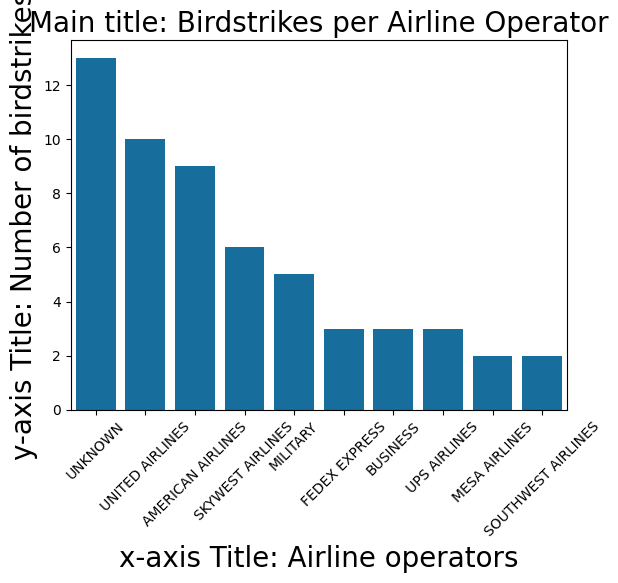

In [58]:
# 4.	We now want to create barplots using the libraries matplotlib and seaborn to visualize occurances of birdstrike per airline operator. Comment the following lines
import seaborn as sns
import matplotlib.pyplot as plt
# Create a colors palette for the bars using seaborns colorblind palette
paired_palette = sns.color_palette("colorblind")
# Set palette as default for the next 10 palette
sns.set_palette(paired_palette, 10)
plt.xticks(rotation=45)
# Set label for x-axis with fontsize of 20
plt.xlabel("x-axis Title: Airline operators", fontsize=20)
# Set label for y-axis with fontsize of 20
plt.ylabel("y-axis Title: Number of birdstrikes", fontsize=20)
#Set title
plt.title("Main title: Birdstrikes per Airline Operator", fontsize=20)
barplot = sns.barplot(x=operators[:10], y=counts[:10])

In [32]:
pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Exercise 2: Survival on titanic dataset

#### Part 1 - Importation of the data and description of the dataset

In [61]:
# 1.	In the first practical session, download the dataset and set the dataset as Dataframe. 
# write your code here
import pandas as pd
df = pd.read_csv("titanic.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
# 2.	Describe the dataset titanic: features, nature of the features, number of observations. 
# write your code here
print("Number of rows:" , df.shape[0])
print("Number of columns:" , df.shape[1])
print("Features (column names):")
print(df.columns.tolist())
print("Data types of each feature:")
print(df.dtypes)

Number of rows: 891
Number of columns: 12
Features (column names):
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Data types of each feature:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [63]:
# 3.	Basic statistics: mean of each variable, quartiles
# write your code here
numeric_stats = df.describe()
print(numeric_stats)

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [68]:
# 4.	Percentage of missing values for each column. Sort by descending values.
# write your code here
missing_percent_col = (df.isnull().sum() / len(df)) * 100
missing_percent_sorted = missing_percent_col.sort_values(ascending=False)
print(missing_percent_sorted)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64


#### Part 2: Remove Irrelevant Features
Remove : 
-	PassengerId
-	Ticket
-	Name
Explain why these columns are removed. ( 2 – 3 Paragraph). (Write in Markdown)

There columns are removed because they are not relevant to the task. Since in this titanic dataset.

The PassengerId is basically a unique indentifier for each passenger. It has no correlation with the survival outcomes. It adds numerical values that has no real meaning for the predection which could confuse the model.

The Ticket column represents ticket numbers, which are unique or semi-unique and do not convey patterns about survival. Including these could add noise instead of useful signal. Name is also use for indentifying each passenger it doesn't relate to the survival rate of the passenger.


#### Part 3: Missing Values 

# write your code here


In [69]:
# 1.	Compute missing value percentages. 
missing_value_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_value_percentage)


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [ ]:
# 2.	Handing missing values:
# •	Age -> median 
# •	Embarked -> mode 
# •	Cabin -> drop or justify decision
df['Age'].fillna(df['Age'].median(), inplace= True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace= True)
df = df.drop(columns=['Cabin'])
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False))


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64


/var/folders/6z/yflnmh5n0r1762zb5y35djhw0000gn/T/ipykernel_30033/1009845864.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace= True)


Part 4: Encoding
Encode: 
-	Sex
-	Embarked 
Use: 
-	Label Encoding or one-hot Encoding

In [ ]:
# write your code here

#### Part 5: Scaling
1.	Scale numerical features: 
•	Age 
•	Fare
Use:
•	Min-Max Scaling or Standardization

In [ ]:
# write your code here

#### Part 6: Outlier Detection

In [ ]:
# 1.	Detect outlier in Dare using IQR 
# write your code here

In [ ]:
# 2. Visualization using boxplot 
# write your code here

In [ ]:
# 3.	Explain whether you remove them or not ?
# write your code here

Basic graphic analysis
We want to understand what features could contributes to a high survival rate. It would make sense if everything would be correlated with a high survival rate. 
1.	We focus on the features ‘Age’ and ‘Sex’
a.	Separate the dataset into men and women 
b.	Display the distribution of the age survivors and non survivors according to the ‘Sex’. 
2.	At first glance is there some link between ‘Embarked’ and ‘Survival’. 
3.	At first glance is there some link between ‘Pclass’ and ‘Survival’.

Write your explaination in the markdowns !

write your explain here ! 